# Hidden Markov Chain Switching Model   

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler
import hmmlearn.hmm as hmm
from hmmlearn.hmm import GaussianHMM
import random
from pykalman import KalmanFilter




warnings.filterwarnings("ignore")



In [2]:
def load_and_prepare_macro_data(asset_dates):
    """
    Loads raw macro variables and ensures they have daily data aligned with asset dates.
    
    Args:
        asset_dates: DatetimeIndex from your asset DataFrame to align the data
    
    Returns:
        DataFrame with all macro variables resampled to daily frequency
    """
    # Load each macro variable with their actual column names
    macro_vars = {
        'dxy': {'filename': 'dxy.csv', 'colname': 'dxy', 'value_col': 'dxy'},
        'creditSpreads': {'filename': 'creditSpreads.csv', 'colname': 'creditSpreads', 'value_col': 'creditSpreads'},
        'realGDP': {'filename': 'realGDP.csv', 'colname': 'realGDP', 'value_col': 'realGDP'}
    }
    
    macro_data = {}
    
    for var_name, info in macro_vars.items():
        try:
            # Load the raw data
            df = pd.read_csv(f'macro/fredData/{info["filename"]}')
            df['date'] = pd.to_datetime(df['date'])
            df.set_index('date', inplace=True)
            
            # Create a complete daily date range
            full_range = pd.date_range(
                start=df.index.min(),
                end=df.index.max(),
                freq='D'
            )
            
            # Resample to daily frequency first
            df = df.reindex(full_range)
            
            # Forward fill missing values (weekends/holidays)
            df = df.fillna(method='ffill')
            
            # Now reindex to match asset dates
            df = df.reindex(asset_dates, method='ffill')
            
            # Store with desired column name using the correct value column
            macro_data[info['colname']] = df[info['value_col']]
            
        except Exception as e:
            print(f"Error loading {var_name}: {e}")
    
    # Combine all macro variables into one DataFrame
    macro_df = pd.DataFrame(macro_data, index=asset_dates)
    
    # Print missing data summary
    print("\nMissing Data Summary:")
    print(macro_df.isnull().sum())
    
    return macro_df

In [3]:

asset = "botto"

# Load asset data
df_1 = pd.read_csv(f"micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

df_2 = pd.read_csv(f"micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

data = pd.merge(df_1, df_2[['total_volume']], left_index=True, right_index=True, how='inner')

data.rename(columns={'total_volume': 'Volume',
                     'open': 'Open',
                     'high': 'High',
                     'low': 'Low',
                     'close': 'Close'}, inplace=True)

# Load and prepare macro data
macro_data = load_and_prepare_macro_data(data.index)

# Merge macro data with asset data
data = data.join(macro_data)

# Print final data quality check
print("\nFinal Dataset Shape:", data.shape)
print("\nMissing Values in Final Dataset:")
print(data.isnull().sum())

data.index.name = 'Date'

data


Missing Data Summary:
dxy              0
creditSpreads    0
realGDP          0
dtype: int64

Final Dataset Shape: (1224, 8)

Missing Values in Final Dataset:
Open             2
High             2
Low              2
Close            2
Volume           0
dxy              0
creditSpreads    0
realGDP          0
dtype: int64


,Open,High,Low,Close,Volume,dxy,creditSpreads,realGDP
Date,,,,,,,,
2021-10-08,NaN,NaN,NaN,NaN,1.080395e+06,94.070000,3.20,21960.388
2021-10-09,NaN,NaN,NaN,NaN,1.080395e+06,94.070000,3.20,21960.388
2021-10-10,0.719424,0.759931,0.447934,0.648066,2.723238e+06,94.070000,3.20,21960.388
2021-10-11,0.635894,1.650000,0.569624,1.250000,3.972173e+06,94.320000,3.20,21960.388
2021-10-12,1.260000,1.610000,0.610605,0.628035,1.660616e+06,94.519997,3.28,21960.388
...,...,...,...,...,...,...,...,...
2025-02-08,0.469022,0.487444,0.442252,0.448746,6.660476e+04,107.778000,2.67,23530.909
2025-02-09,0.448543,0.458938,0.444837,0.455472,7.684072e+04,107.778000,2.67,23530.909
2025-02-10,0.454603,0.464728,0.442692,0.449543,9.642898e+04,108.320000,2.66,23530.909


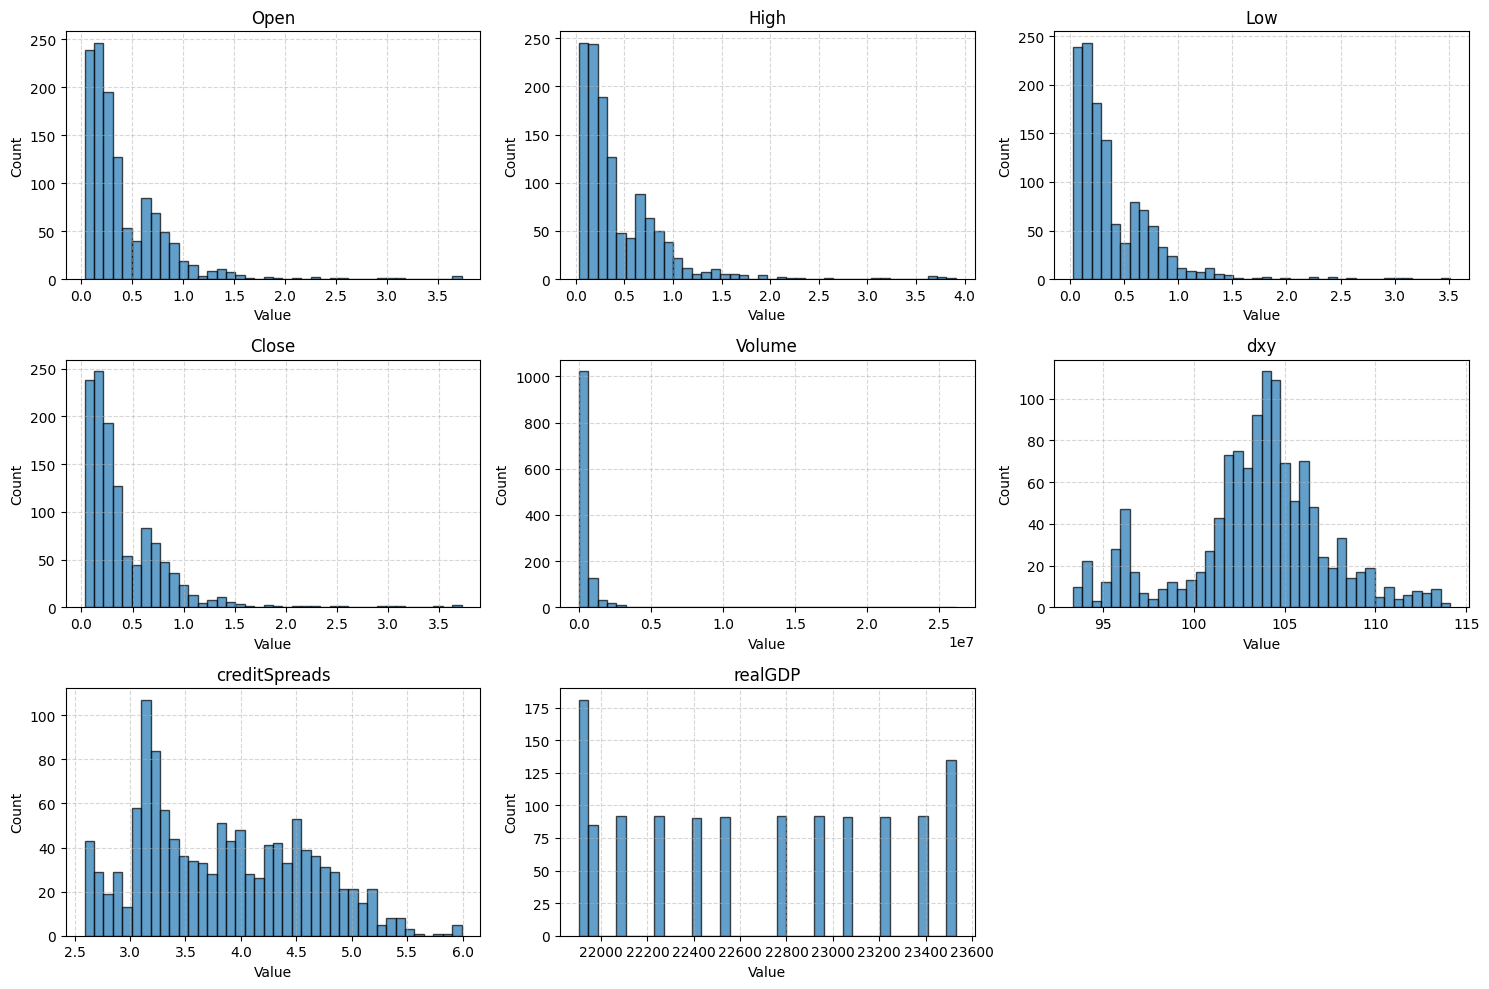

In [4]:


def plot_feature_distributions(df, feature_cols=None, bins=50, figsize=(15, 10)):
    """
    Plots the distribution (histograms) of specified feature columns in a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing your features.
    feature_cols : list of str, optional
        List of columns to plot. If None, attempts to plot all numeric columns 
        except non-feature columns (e.g., 'symbol', 'interval', 'Date').
    bins : int, optional
        Number of histogram bins. Default 50.
    figsize : tuple, optional
        Figure size for the overall plot. Default (15, 10).
    
    Returns
    -------
    None (Displays a Matplotlib figure of histograms)
    """
    
    # If user does not specify feature columns, attempt to infer from numeric columns
    if feature_cols is None:
        # Exclude any known non-feature columns
        exclude_cols = {'symbol', 'interval', 'Date'}
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                        if col not in exclude_cols]
    
    n_features = len(feature_cols)
    
    # Decide on subplot grid (approx square layout)
    n_cols = int(np.ceil(np.sqrt(n_features)))
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to easily iterate even if there's only 1 row
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        # Drop NaN to avoid issues in hist
        valid_data = df[col].dropna()
        ax.hist(valid_data, bins=bins, edgecolor='k', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Count')
        ax.set_xlabel('Value')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


# Example usage:
# Assuming 'df' is your feature DataFrame:
# plot_feature_distributions(df)
# or specify columns explicitly:
plot_feature_distributions(data, feature_cols=data.columns, bins=40)

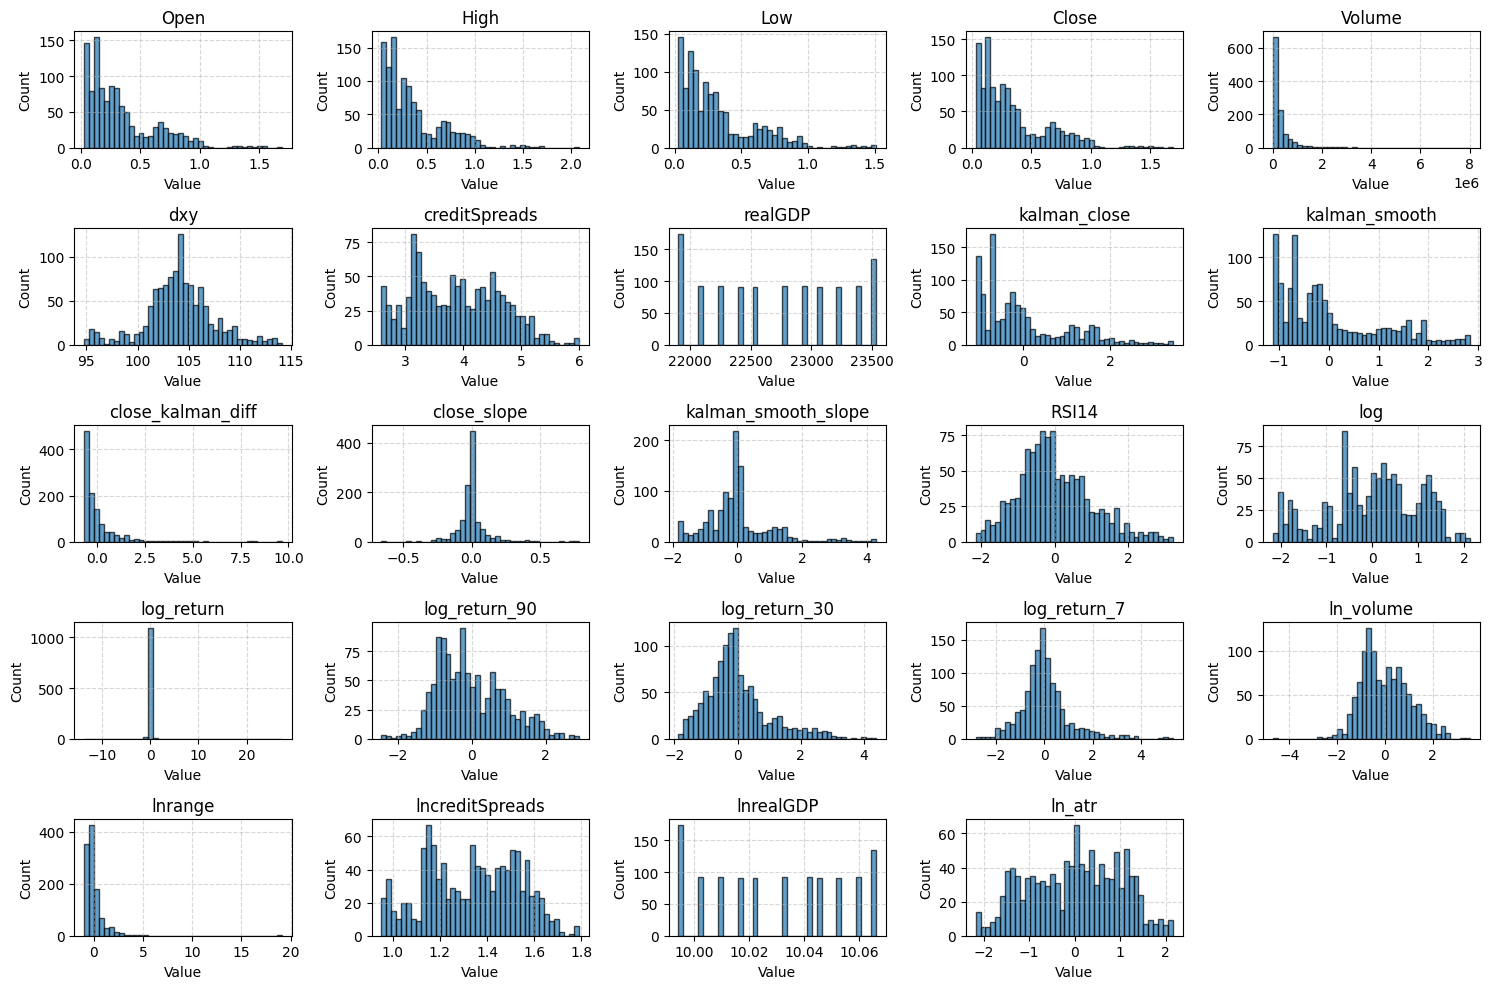

In [5]:

def calculate_atr(high, low, close, window=14):
    """
    Calculate the Average True Range (ATR).

    ATR is defined as the rolling average (window=14 by default) of the True Range.
    True Range (TR) is the maximum of:
      - (High - Low)
      - Absolute(High - previous Close)
      - Absolute(Low - previous Close)
    """
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=window, min_periods=window).mean()
    return atr

# Setup Kalman Filter (make sure data is loaded before setting initial_state_mean)
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=None,  # will be set after loading data
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

# Assume 'data' has already been loaded and merged with macro data.
df = data.copy()
df.dropna(inplace=True)

# Apply the Kalman filter on Close prices
kf.initial_state_mean = df['Close'].iloc[0]
state_means, state_covariances = kf.filter(df['Close'].values)
df['kalman_close'] = state_means.flatten()
smoothed_state_means, smoothed_state_covariances = kf.smooth(df['kalman_close'].values)
df['kalman_smooth'] = smoothed_state_means.flatten()
df['close_kalman_diff'] = np.abs(df['Close'] - df['kalman_smooth'])
df['close_slope'] = df['Close'].diff(periods=7)
df['kalman_smooth_slope'] = df['kalman_smooth'].diff(periods=7)

# Compute technical indicators
df['RSI14'] = ta.rsi(df['Close'], length=14)

df['log'] = np.log(df['Close'])
df['log_return'] = df['log'].pct_change()
df['log_return_90'] = df['log'].diff(periods=90)
df['log_return_30'] = df['log'].diff(periods=30)
df['log_return_7'] = df['log'].diff(periods=7)
df['ln_volume'] = np.log(df['Volume']+1e-10)
df['lnrange'] = np.log(df['High'] / df['Low'])
df['lncreditSpreads'] = np.log(df['creditSpreads'])
df['lnrealGDP'] = np.log(df['realGDP'])

# Compute moving averages
#df['MA30'] = df['Close'].rolling(window=30).mean()
#df['MA365'] = df['Close'].rolling(window=365).mean()
#df['lnMA30'] = np.log(df['MA30'])
#df['lnMA365'] = np.log(df['MA365'])

# Compute rolling volatility (close-to-close)
#df['vol30'] = df['log_return'].rolling(window=30).std()

# Calculate ATR (using a 14-day window) and add as a new feature.
# (Removed the np.log() transformation so ATR remains in its natural scale.)
df['ln_atr'] = np.log(calculate_atr(df['High'], df['Low'], df['Close'], window=14))

# Drop rows with any NaN values (this will remove the early rows affected by rolling calculations)
df.dropna(inplace=True)

# Scale features
scaler = StandardScaler()
features_to_scale = [
    'log', 'log_return', 'lnrange',
    'RSI14', 'log_return_30', 'log_return_7', 'ln_atr',
    'kalman_close', 'kalman_smooth', 'kalman_smooth_slope', 
    'close_kalman_diff', 'ln_volume'
]
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Add symbol and interval columns
#symbol = 'BTC'
#interval = '1D'
#df.insert(0, 'symbol', symbol.upper())
#df.insert(1, 'interval', interval.upper())

plot_feature_distributions(df, feature_cols=df.columns, bins=40)

In [6]:
df

,Open,High,Low,Close,Volume,dxy,creditSpreads,realGDP,kalman_close,kalman_smooth,...,log,log_return,log_return_90,log_return_30,log_return_7,ln_volume,lnrange,lncreditSpreads,lnrealGDP,ln_atr
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-08,0.551915,0.551915,0.475250,0.528684,367225.545589,95.739998,3.20,21903.850,1.065674,1.104331,...,0.887021,0.057273,-0.203602,-0.819015,-0.350503,0.713099,0.685003,1.163151,9.994418,1.146037
2022-01-09,0.530683,0.541728,0.484460,0.503429,498980.713993,95.739998,3.20,21903.850,1.020674,1.072325,...,0.834683,0.065210,-0.909456,-0.733431,-0.559093,0.997793,0.249001,1.163151,9.994418,1.181078
2022-01-10,0.496554,0.534995,0.482463,0.520008,430525.274205,95.989998,3.24,21903.850,0.985660,1.040512,...,0.869328,-0.032844,-0.188752,-0.463999,-1.721214,0.860771,0.152450,1.175573,9.994418,1.203898
2022-01-11,0.518605,0.542331,0.504862,0.525417,374406.600204,95.620003,3.18,21903.850,0.955838,1.008937,...,0.880393,-0.008027,-0.304922,-0.590908,-1.595706,0.731082,-0.213673,1.156881,9.994418,1.174475
2022-01-12,0.522182,0.549463,0.516017,0.533739,365111.743880,95.000000,3.06,21903.850,0.931716,0.977592,...,0.897196,-0.014821,-0.081565,-0.549717,-1.013805,0.707739,-0.314993,1.118415,9.994418,1.156223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-08,0.469022,0.487444,0.442252,0.448746,66604.755349,107.778000,2.67,23530.909,0.821671,1.042426,...,0.711735,0.044895,-0.324096,-1.144471,-1.080064,-0.872168,0.082623,0.982078,10.066070,0.861330
2025-02-09,0.448543,0.458938,0.444837,0.455472,76840.719296,107.778000,2.67,23530.909,0.783378,1.031783,...,0.727643,-0.010194,-0.297455,-1.017283,-0.579259,-0.739420,-0.679188,0.982078,10.066070,0.832221
2025-02-10,0.454603,0.464728,0.442692,0.449543,96428.979431,108.320000,2.66,23530.909,0.746688,1.023382,...,0.713633,0.017660,-0.163777,-1.006018,-0.671502,-0.528566,-0.478952,0.978326,10.066070,0.751622


In [7]:
def split_date_wise(data, 
                    embargo_percent=0.01, 
                    train_start_date=None,
                    train_end_date=None):
    
    #throw error if data in improper form
    if isinstance(data, pd.DataFrame) == False or 'Date' not in data:
        raise ValueError("""Data must be of type pd.DataFrame and contain a 
                         'date' column.""")
       
    #handle no dates given
    if train_start_date == None and train_end_date == None:
        raise ValueError("""At least one of train_start_date and 
                         train_end_date params must be given an argument.""")
 
    #handle end date given but no start
    if train_end_date != None and train_start_date == None:
        train_start_date = data['Date'][0]
 
    #handle start date given but no end
    if train_start_date != None and train_end_date == None:
        raise ValueError('end_date must be given.')
     
    #find start index
    #consider forcing start date to nearest trade day if non-trading day given
    start_index = -1
    for i in range(len(data)):    
        if data['Date'][i] == pd.to_datetime(train_start_date):
            start_index = i 
    
    #raise error if day train_start_date not in data
    if start_index < 0:
        raise ValueError('train_start_date of: ' + train_start_date + 
                         ' not in data.'
                         +' Make sure given date is trading day.')
    
    #find end index
    end_index = -1
    for i in range(len(data)):
        if data['Date'][i] == pd.to_datetime(train_end_date):
            end_index = i
    
    #throw error if day train_start_date not in data
    if end_index < 0:
        raise ValueError(
            'train_end_date of: ' + train_end_date + ' not in data.'
                         +' Make sure given date is trading day.')
    
    #set train, test and embargo set    
    train = data[start_index:end_index+1]
    test = data[round((end_index+1)+(embargo_percent*len(data))):]
    embargo = data[end_index+1:round(end_index+(embargo_percent*len(data))+1)]
    
    #throw error if test set empty
    if len(test) == 0:
        raise ValueError(
            'No data in test set, reduce embargo size or date range.')
    
    #warn if embargo length short
    if len(embargo) < 5:
        import warnings
        warnings.warn("""<5 embargoed data points means data the model was
                      trained on is likely to leak into test set.""")
      
    return train, embargo, test

def split_rand(data, train_percent):

    train = data[np.random.rand(len(data)) < 0.8]
    test = data[~np.random.rand(len(data)) < 0.8]
    
    return train, test

In [8]:
df.reset_index(inplace=True)
train, embargo, test = split_date_wise(df,
                                     embargo_percent=0.05,
                                     train_start_date=None,
                                     train_end_date='2023-12-31')

In [9]:

# Set random seeds for reproducibility
np.random.seed(4214609)  # for numpy operations
random.seed(4214609)     # for Python's random module

# ln vor btc has bad results du to dirty data at the beginning, shallow liquidity

features_btc = ['Date', 'log_return', 'log_return_30', 'log_return_7', 'RSI14', 'ln_atr', 'kalman_smooth_slope'] 

features_eth = ['Date', 'kalman_smooth_slope', 'ln_atr', 'log_return_30', 'RSI14', 'ln_volume']

features_link = ['Date', 'log_return_30', 'RSI14', 'ln_atr', 'ln_volume', 'kalman_smooth_slope']

features_sol = ['Date', 'log_return_30', 'RSI14', 'ln_atr', 'ln_volume', 'kalman_smooth_slope']

features_ray = ['Date', 'log_return_30', 'RSI14', 'ln_atr', 'ln_volume', 'kalman_smooth_slope']

features_vista = ['Date', 'log_return_30', 'RSI14', 'ln_atr', 'ln_volume', 'kalman_smooth_slope']

#set features
f_train = train[features_vista].set_index('Date')

f_test = test[features_vista].set_index('Date')

hmm = GaussianHMM(n_components=3, 
                  covariance_type="full", n_iter=100000000, verbose=False).fit(f_train)
 
#predict hidden states on test set
hidden_states = hmm.predict(f_test)


## Long-Only


In [29]:

#state 0 mean return and var
s0_mean_ret = hmm.means_[0]
s0_mean_ret = s0_mean_ret[0]
s0_var_ret = np.diag(hmm.covars_[0])
s0_var_ret = s0_var_ret[0]
 
#state 1 mean return and var
s1_mean_ret = hmm.means_[1]
s1_mean_ret = s1_mean_ret[0]
s1_var_ret = np.diag(hmm.covars_[1])
s1_var_ret = s1_var_ret[0]
 
#state 2 mean return and var
s2_mean_ret = hmm.means_[2]
s2_mean_ret = s2_mean_ret[0]
s2_var_ret = np.diag(hmm.covars_[2])
s2_var_ret = s2_var_ret[0]
 
#find favoured state (return wise, no account for var)
if s0_mean_ret > s1_mean_ret and s0_mean_ret > s2_mean_ret:
    fav_state = 0    
if s1_mean_ret > s0_mean_ret and s1_mean_ret > s2_mean_ret:
    fav_state = 1
if s2_mean_ret > s0_mean_ret and s2_mean_ret > s1_mean_ret:
    fav_state = 2
 
#create time series of states
hmm_state_series = test.copy()
hmm_state_series.drop(['Open','High','Low','Close','Volume','log_return'],
                      axis=1,inplace=True)
 
hmm_state_series['hidden_state'] = hidden_states
 
hmm_state_series.loc[hmm_state_series['hidden_state'] 
                     == fav_state,'state'] = 'Long'
 
hmm_state_series.loc[hmm_state_series['hidden_state'] 
                     != fav_state,'state'] = 'Flat'
 
hmm_state_series['return'] = hmm_state_series['log'].pct_change()
                                                               
#create df of state certainty
p_of_states = pd.DataFrame(hmm.predict_proba(f_test))
 
#create df of probability curr state is favourable (mean_ret > 0)
fav = p_of_states[fav_state]
p_of_states_fav_unfav = pd.DataFrame(fav)
 
unfav = []
for i in fav:
    j = 1-i
    unfav.append(j)
 
p_of_states_fav_unfav.insert(1,'unfav',unfav)

array([[<Axes: title={'center': '1'}>, <Axes: title={'center': 'unfav'}>]],
      dtype=object)

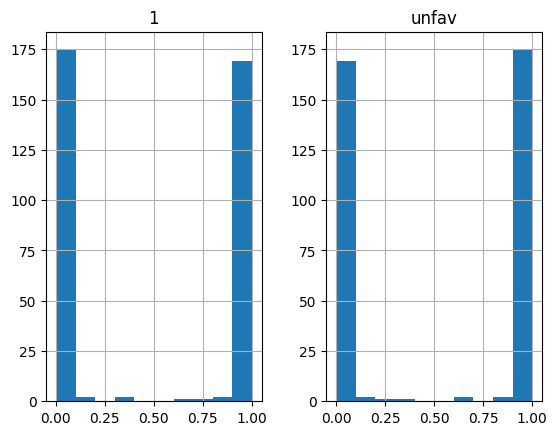

In [30]:
p_of_states_fav_unfav.hist()

## Long Short

In [10]:
import numpy as np
import pandas as pd

# Extract the first dimension's mean (i.e., mean log_return) for each state
s0_mean_ret = hmm.means_[0][0]  
s1_mean_ret = hmm.means_[1][0]
s2_mean_ret = hmm.means_[2][0]

state_means = [s0_mean_ret, s1_mean_ret, s2_mean_ret]
print("State means:", state_means)  # Debug print

# Identify which index (0,1,2) has the highest and lowest returns
max_state = np.argmax(state_means)
min_state = np.argmin(state_means)
print(f"Max state: {max_state}, Min state: {min_state}")  # Debug print

hmm_state_series = test.copy()

# Drop unneeded columns
columns_to_keep = ['log']  
hmm_state_series = hmm_state_series[columns_to_keep]

# Add state information
hmm_state_series['hidden_state'] = hidden_states

# Default everything to "Flat"
hmm_state_series['state'] = 'Flat'

# Assign Long/Short states
hmm_state_series.loc[hmm_state_series['hidden_state'] == max_state, 'state'] = 'Long'
hmm_state_series.loc[hmm_state_series['hidden_state'] == min_state, 'state'] = 'Short'

# Add returns
hmm_state_series['return'] = hmm_state_series['log'].pct_change()

# Get state probabilities with proper index and column names
p_of_states = pd.DataFrame(
    hmm.predict_proba(f_test),
    index=f_test.index,
    columns=[f'state_{i}' for i in range(3)]  # Create column names
)

# Create fav/unfav probabilities
p_of_states_fav_unfav = pd.DataFrame(index=f_test.index)
p_of_states_fav_unfav['fav'] = p_of_states[f'state_{max_state}']  # Use string column name
p_of_states_fav_unfav['unfav'] = 1 - p_of_states_fav_unfav['fav']

# Debug prints
print("\nShape of p_of_states:", p_of_states.shape)
print("Shape of p_of_states_fav_unfav:", p_of_states_fav_unfav.shape)
print("\nFirst few rows of p_of_states_fav_unfav:")
print(p_of_states_fav_unfav.head())

State means: [-0.8637319461829802, 1.519589107939528, 0.023334468915778967]
Max state: 1, Min state: 0

Shape of p_of_states: (352, 3)
Shape of p_of_states_fav_unfav: (352, 2)

First few rows of p_of_states_fav_unfav:
                      fav  unfav
Date                            
2024-02-27  2.136829e-189    1.0
2024-02-28   1.000000e+00    0.0
2024-02-29   1.000000e+00    0.0
2024-03-01   1.000000e+00    0.0
2024-03-02   1.000000e+00    0.0


array([[<Axes: title={'center': 'fav'}>,
        <Axes: title={'center': 'unfav'}>]], dtype=object)

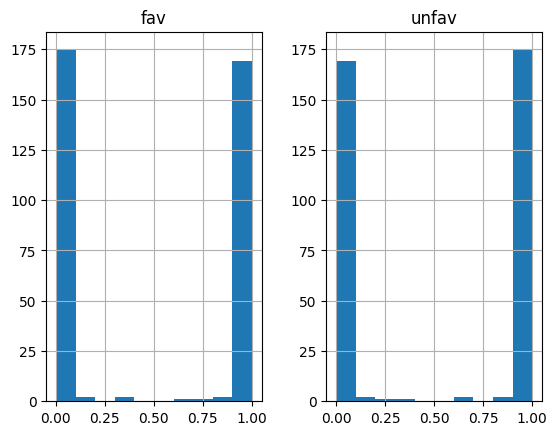

In [11]:
p_of_states_fav_unfav.hist()

## Long Only Trades

In [31]:
def transact_at_open(test, hmm_state_series, p_of_states_fav_unfav):
    """
    Given the test data (with price info), the HMM state assignments,
    and the probability DataFrame (with a column 'unfav' that gives the probability 
    that the current state is not the favorable one), this function:
      - Merges everything into one DataFrame.
      - Shifts the state signal forward one row (since the state is determined from close values)
      - Computes the daily open-to-open returns.
      - Computes a strategy’s daily and cumulative returns assuming you trade only
        at the open when your signal (Long vs Flat) changes.
    
    Parameters:
      test : pd.DataFrame
          The test dataset that includes at least a Date and Open price column.
      hmm_state_series : pd.DataFrame
          The DataFrame that (at a minimum) contains the columns 
          'hidden _state' (the raw state assigned by the HMM) and
          'state' (a text label such as "Long" or "Flat").
      p_of_states_fav_unfav : pd.DataFrame
          A DataFrame (indexed by Date) that contains at least the column 
          'unfav' giving the probability that the current state is unfavorable.
    
    Returns:
      result : pd.DataFrame
          A copy of the test set with extra columns:
            - 'hidden _state' and 'state' (the original HMM assignments)
            - 'unfav' (the unfavored probability)
            - 'signal' (the state signal shifted forward one row)
            - 'position' (1 when signal == "Long", else 0)
            - 'open_return' (next day’s open-to-open return, computed as Open[i+1] / Open[i] - 1)
            - 'strategy_return' (daily return if in a long position, else 0)
            - 'cum_strategy_return' (cumulative return for the strategy)
            - 'cum_buy_hold_return' (cumulative return from simply trading the asset’s open price)
            - 'trade' (flag marking a change in signal)
    """
    
    # Make a copy of test data to start with
    result = test.copy()
    
    # Ensure p_of_states_fav_unfav has the same index as test
    p_of_states_fav_unfav.index = test.index
    
    # Join in the HMM state information
    result = result.join(hmm_state_series[['hidden_state', 'state']])
    
    # Now join the unfav probability
    result = result.join(p_of_states_fav_unfav['unfav'])
    
    # Verify the join worked
    if result['unfav'].isna().all():
        print("Warning: unfav column is all NaN. Debugging info:")
        print(f"result index: {result.index[:5]}")
        print(f"p_of_states_fav_unfav index: {p_of_states_fav_unfav.index[:5]}")
    
    # Rest of the function remains the same
    result['signal'] = result['state'].shift(1)
    result['position'] = np.where(result['signal'] == 'Long', 1, 0)
    result['next_open'] = result['Open'].shift(-1)
    result['open_return'] = result['next_open'] / result['Open'] - 1
    result['open_return'] = result['open_return'].fillna(0)
    result['strategy_return'] = result['position'] * result['open_return']
    result['trade'] = (result['signal'] != result['signal'].shift(1)).astype(int)
    result['cum_strategy_return'] = (1 + result['strategy_return']).cumprod() - 1
    result['cum_buy_hold_return'] = (1 + result['open_return']).cumprod() - 1
    result.drop(['next_open'], axis=1, inplace=True)
    
    return result

# =============================================================================
# EXAMPLE USAGE:
# (Assuming that you have already defined the following from your earlier script:)
#   - test           : your test set DataFrame (with Date, Open, etc.)
#   - hmm_state_series: the DataFrame holding the HMM-assigned states and the "Long"/"Flat" labels.
#   - p_of_states_fav_unfav: DataFrame with the probabilities (including column 'unfav').
# =============================================================================

# For example, you might call:
compiled_df = transact_at_open(test, hmm_state_series, p_of_states_fav_unfav)
compiled_df

,Date,Open,High,Low,Close,Volume,dxy,creditSpreads,realGDP,kalman_close,...,hidden_state,state,unfav,signal,position,open_return,strategy_return,trade,cum_strategy_return,cum_buy_hold_return
780,2024-02-27,0.406100,0.506054,0.397540,0.490149,3.629556e+05,103.830002,3.26,23053.545,0.113838,...,0,Flat,1.0,None,0,0.208402,0.000000,1,0.000000,0.208402
781,2024-02-28,0.490732,0.490840,0.424354,0.424764,3.956657e+05,103.980003,3.31,23053.545,0.132310,...,1,Long,0.0,Flat,0,-0.132763,-0.000000,1,0.000000,0.047971
782,2024-02-29,0.425581,0.527701,0.421516,0.501968,4.465551e+05,104.160004,3.29,23053.545,0.175593,...,1,Long,0.0,Long,1,0.181498,0.181498,1,0.181498,0.238175
783,2024-03-01,0.502823,0.580160,0.502823,0.541076,1.831896e+06,103.860001,3.32,23053.545,0.228218,...,1,Long,0.0,Long,1,0.073982,0.073982,0,0.268908,0.329778
784,2024-03-02,0.540023,0.755193,0.540023,0.755193,2.492527e+06,103.860001,3.32,23053.545,0.349521,...,1,Long,0.0,Long,1,0.396194,0.396194,0,0.771642,0.856629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,2025-02-08,0.469022,0.487444,0.442252,0.448746,6.660476e+04,107.778000,2.67,23530.909,0.821671,...,0,Flat,1.0,Flat,0,-0.043663,-0.000000,0,2.999046,0.104514
1128,2025-02-09,0.448543,0.458938,0.444837,0.455472,7.684072e+04,107.778000,2.67,23530.909,0.783378,...,0,Flat,1.0,Flat,0,0.013510,0.000000,0,2.999046,0.119436
1129,2025-02-10,0.454603,0.464728,0.442692,0.449543,9.642898e+04,108.320000,2.66,23530.909,0.746688,...,0,Flat,1.0,Flat,0,-0.013863,-0.000000,0,2.999046,0.103918
1130,2025-02-11,0.448301,0.463967,0.448301,0.461064,8.116576e+04,108.193001,2.66,23530.909,0.717452,...,0,Flat,1.0,Flat,0,0.025365,0.000000,0,2.999046,0.131918


## Long Short Trades    

In [12]:
def transact_at_open(test, hmm_state_series, p_of_states_fav_unfav):
    """
    Now includes short positions when state=='Short'.
    """
    
    # Make a copy of test data
    result = test.copy()
    
    # Ensure alignment of indexes
    p_of_states_fav_unfav.index = test.index
    
    # Merge HMM state info
    result = result.join(hmm_state_series[['hidden_state', 'state']])
    
    # Merge “unfav” probability
    result = result.join(p_of_states_fav_unfav['unfav'])
    
    # Shift the signal by 1 day (so you trade at today's open
    # based on yesterday's close-based regime)
    result['signal'] = result['state'].shift(1)
    
    # Map the signal to a position: +1 for Long, –1 for Short, 0 for Flat
    def map_position(signal):
        if signal == 'Long':
            return 1
        elif signal == 'Short':
            return -1
        else:
            return 0

    result['position'] = result['signal'].apply(map_position)
    
    # Next day's open price for return computation
    result['next_open'] = result['Open'].shift(-1)
    
    # Open-to-open daily return
    result['open_return'] = result['next_open'] / result['Open'] - 1
    result['open_return'] = result['open_return'].fillna(0)
    
    # Strategy’s return if in a position (positive or negative)
    # position * open_return automatically handles shorting
    result['strategy_return'] = result['position'] * result['open_return']
    
    # Mark when you change signals
    result['trade'] = (result['signal'] != result['signal'].shift(1)).astype(int)
    
    # Cumulative return series
    result['cum_strategy_return'] = (1 + result['strategy_return']).cumprod() - 1
    result['cum_buy_hold_return'] = (1 + result['open_return']).cumprod() - 1
    
    result.drop(['next_open'], axis=1, inplace=True)
    
    return result

compiled_df = transact_at_open(test, hmm_state_series, p_of_states_fav_unfav)
compiled_df


,Date,Open,High,Low,Close,Volume,dxy,creditSpreads,realGDP,kalman_close,...,hidden_state,state,unfav,signal,position,open_return,strategy_return,trade,cum_strategy_return,cum_buy_hold_return
780,2024-02-27,0.406100,0.506054,0.397540,0.490149,3.629556e+05,103.830002,3.26,23053.545,0.113838,...,0,Short,1.0,None,0,0.208402,0.000000,1,0.000000,0.208402
781,2024-02-28,0.490732,0.490840,0.424354,0.424764,3.956657e+05,103.980003,3.31,23053.545,0.132310,...,1,Long,0.0,Short,-1,-0.132763,0.132763,1,0.132763,0.047971
782,2024-02-29,0.425581,0.527701,0.421516,0.501968,4.465551e+05,104.160004,3.29,23053.545,0.175593,...,1,Long,0.0,Long,1,0.181498,0.181498,1,0.338357,0.238175
783,2024-03-01,0.502823,0.580160,0.502823,0.541076,1.831896e+06,103.860001,3.32,23053.545,0.228218,...,1,Long,0.0,Long,1,0.073982,0.073982,0,0.437372,0.329778
784,2024-03-02,0.540023,0.755193,0.540023,0.755193,2.492527e+06,103.860001,3.32,23053.545,0.349521,...,1,Long,0.0,Long,1,0.396194,0.396194,0,1.006850,0.856629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,2025-02-08,0.469022,0.487444,0.442252,0.448746,6.660476e+04,107.778000,2.67,23530.909,0.821671,...,0,Short,1.0,Short,-1,-0.043663,0.043663,0,7.913455,0.104514
1128,2025-02-09,0.448543,0.458938,0.444837,0.455472,7.684072e+04,107.778000,2.67,23530.909,0.783378,...,0,Short,1.0,Short,-1,0.013510,-0.013510,0,7.793031,0.119436
1129,2025-02-10,0.454603,0.464728,0.442692,0.449543,9.642898e+04,108.320000,2.66,23530.909,0.746688,...,0,Short,1.0,Short,-1,-0.013863,0.013863,0,7.914926,0.103918
1130,2025-02-11,0.448301,0.463967,0.448301,0.461064,8.116576e+04,108.193001,2.66,23530.909,0.717452,...,0,Short,1.0,Short,-1,0.025365,-0.025365,0,7.688802,0.131918


<Axes: >

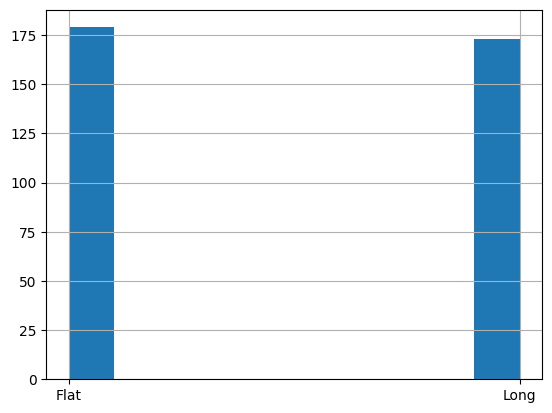

In [32]:
compiled_df['state'].hist()

In [33]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_hmm_results(df):
    """
    Given a DataFrame (such as that returned by transact_at_open()) that includes:
      - Date (as a column)
      - 'hidden _state': the raw state from the HMM (e.g. 0, 1, or 2)
      - 'cum_buy_hold_return': cumulative return from buying and holding the asset
      - 'cum_strategy_return': cumulative return from the HMM-based strategy
      - 'unfav': the probability that the state is unfavored
    this function produces a two-panel interactive Plotly plot.
    """
    
    # Ensure Date is datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    # Create figure with secondary y-axis
    fig = make_subplots(rows=2, cols=1, 
                       shared_xaxes=True,
                       vertical_spacing=0.1,
                       row_heights=[0.7, 0.3])

    # Top Panel: Returns
    # Scatter plot for buy & hold returns colored by state
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_buy_hold_return'],
            mode='markers',
            name='Buy & Hold',
            marker=dict(
                size=4,
                color=df['hidden_state'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title='Hidden State')
            )
        ),
        row=1, col=1
    )
    
    # Line plot for strategy returns
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_strategy_return'],
            mode='lines',
            name='HMM Strategy',
            line=dict(color='red', width=2)
        ),
        row=1, col=1
    )
    
    # Bottom Panel: Unfavored Probability
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['unfav'],
            mode='lines',
            name='Unfavored Probability',
            line=dict(color='black', width=2)
        ),
        row=2, col=1
    )
    
    # Update layout
    fig.update_layout(
        title='HMM-Regime Based Strategy Analysis',
        template='plotly_white',
        height=800,
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Update y-axes labels
    fig.update_yaxes(title_text="Cumulative Return", row=1, col=1)
    fig.update_yaxes(title_text="Unfavored Probability", row=2, col=1)
    
    # Update x-axis label
    fig.update_xaxes(title_text="Date", row=2, col=1)
    
    # Show the plot
    fig.show()

# Example usage:
plot_hmm_results(compiled_df)

In [27]:
compiled_df.tail(60)

,Date,Open,High,Low,Close,Volume,dxy,creditSpreads,realGDP,kalman_close,...,hidden_state,state,unfav,signal,position,open_return,strategy_return,trade,cum_strategy_return,cum_buy_hold_return
1072,2024-12-15,1.008000,1.013000,0.933303,0.950173,4.012043e+05,107.000000,2.68,23530.909,1.651910,...,1,Long,0.000000e+00,Long,1,-0.057942,-0.057942,0,8.295470,1.338326
1073,2024-12-16,0.949594,1.025000,0.922864,1.009000,3.721202e+05,106.860001,2.69,23530.909,1.725128,...,1,Long,0.000000e+00,Long,1,0.061506,0.061506,0,8.867199,1.482147
1074,2024-12-17,1.008000,1.008000,0.855733,0.864921,5.333431e+05,106.959999,2.75,23530.909,1.741798,...,1,Long,0.000000e+00,Long,1,-0.141040,-0.141040,0,7.475533,1.132066
1075,2024-12-18,0.865832,0.869383,0.758744,0.762396,4.762757e+05,108.029999,2.73,23530.909,1.721601,...,1,Long,0.000000e+00,Long,1,-0.122616,-0.122616,0,6.436295,0.870640
1076,2024-12-19,0.759667,0.848001,0.694515,0.706729,9.337108e+05,108.410004,2.91,23530.909,1.684168,...,1,Long,0.000000e+00,Long,1,-0.074152,-0.074152,0,5.884878,0.731928
1077,2024-12-20,0.703336,0.760782,0.632492,0.760409,3.777538e+05,107.620003,2.86,23530.909,1.668769,...,1,Long,0.000000e+00,Long,1,0.081873,0.081873,0,6.448561,0.873726
1078,2024-12-21,0.760920,0.795131,0.741300,0.765706,4.946866e+05,107.620003,2.86,23530.909,1.656658,...,1,Long,0.000000e+00,Long,1,0.006765,0.006765,0,6.498954,0.886402
1079,2024-12-22,0.766068,0.770298,0.707793,0.715380,2.228922e+05,107.620003,2.86,23530.909,1.628379,...,1,Long,0.000000e+00,Long,1,-0.065836,-0.065836,0,6.005252,0.762209
1080,2024-12-23,0.715633,0.837671,0.701187,0.812539,6.564792e+05,108.040001,2.85,23530.909,1.636227,...,1,Long,0.000000e+00,Long,1,0.137053,0.137053,0,6.965346,1.003726
1081,2024-12-24,0.813713,0.829864,0.765260,0.829864,5.168567e+05,108.260002,2.86,23530.909,1.649290,...,1,Long,0.000000e+00,Long,1,0.017592,0.017592,0,7.105474,1.038976


array([[<Axes: title={'center': 'strategy_return'}>,
        <Axes: title={'center': 'open_return'}>]], dtype=object)

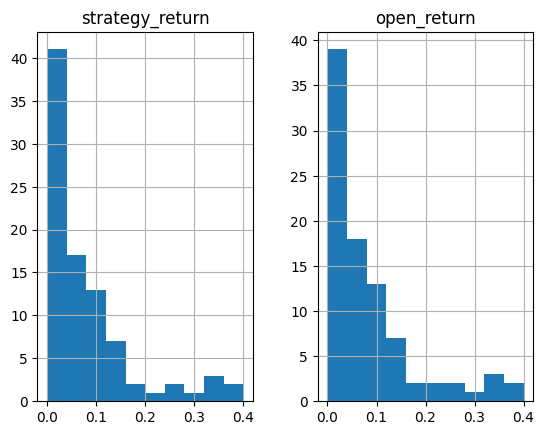

In [28]:
compiled_df[(compiled_df['strategy_return'] >= 0.0) & (compiled_df['open_return'] >= 0.0)][['strategy_return', 'open_return']].hist()